# Sales Forecasting — Linear Regression Project
**Dataset:** [Sales Forecasting Dataset (Kaggle)](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting)

This notebook works through the Linear Regression tasks (Phase 1–3 of the assignment) one by one:
data collection → preprocessing → EDA → assumption checks → linear regression → feature engineering
(interactions/polynomial features) → polynomial regression → Ridge/Lasso → cross-validation.

Each section has a **What** (what the code does) and **Why** (why this step matters) before the code.

## Phase 1 — Data Collection

**What:** Download the sales dataset from Kaggle (`rohitsahoo/sales-forecasting`) and load it into a pandas DataFrame.

**Why:** We need real, reasonably sized data with a mix of numeric and categorical features to make regression
and feature engineering meaningful. This dataset has order dates, ship dates, sales amounts, and categorical
fields (segment, region, category), which gives us room for real preprocessing and feature engineering work.

> Download the CSV manually from Kaggle (login required) and place it as `train.csv` in your working folder,
> or use the Kaggle API (`kaggle datasets download -d rohitsahoo/sales-forecasting`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
# Load dataset (adjust filename/path as needed after downloading from Kaggle)
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Phase 2 — Data Preprocessing

### 2.1 Handle missing values

**What:** Check every column for missing values and decide how to treat each one (drop, impute with
median/mode, or flag as missing).

**Why:** Linear regression (and sklearn in general) cannot fit on NaNs. How we handle missingness also
affects bias — e.g. filling with the mean can shrink variance, while dropping rows can lose information
if missingness isn't random.

In [3]:
print(df.isnull().sum().sort_values(ascending=False))

# Example strategy: drop columns that are almost entirely missing / not useful (IDs, names),
# impute numeric columns with median, categorical columns with mode.
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())

Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Remaining missing values: 0


### 2.2 Feature Engineering — build numeric predictors

**What:** Convert raw columns (dates, categories) into usable numeric features: extract order year/month,
compute shipping delay in days, and one-hot encode categorical columns like `Ship Mode`, `Segment`, `Region`,
`Category`.

**Why:** Linear regression needs numeric inputs. Feature engineering is often what determines model quality
more than the choice of algorithm — raw dates and text categories carry no linear signal on their own, but
derived features (delay in days, month seasonality, encoded category) do. This is also where we create the
"interaction" and "polynomial" groundwork used later in Phase 3.

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Engineered features
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Year"] = df["Order Date"].dt.year
df["Shipping_Delay_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# One-hot encode key categorical predictors
cat_features = ["Ship Mode", "Segment", "Region", "Category"]
cat_features = [c for c in cat_features if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

df_encoded.head()

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Country,City,State,Postal Code,Product ID,Sub-Category,Product Name,Sales,Order_Month,Order_Year,Shipping_Delay_Days,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,1,CA-2017-152156,2017-08-11,2017-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420.0,FUR-BO-10001798,Bookcases,Bush Somerset Collection Bookcase,261.9600,8.0,2017.0,92.0,False,True,False,False,False,False,True,False,False,False
1,2,CA-2017-152156,2017-08-11,2017-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420.0,FUR-CH-10000454,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,8.0,2017.0,92.0,False,True,False,False,False,False,True,False,False,False
2,3,CA-2017-138688,2017-12-06,NaT,DV-13045,Darrin Van Huff,United States,Los Angeles,California,90036.0,OFF-LA-10000240,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12.0,2017.0,NaN,False,True,False,True,False,False,False,True,True,False
3,4,US-2016-108966,2016-11-10,NaT,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311.0,FUR-TA-10000577,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11.0,2016.0,NaN,False,False,True,False,False,False,True,False,False,False
4,5,US-2016-108966,2016-11-10,NaT,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311.0,OFF-ST-10000760,Storage,Eldon Fold 'N Roll Cart System,22.3680,11.0,2016.0,NaN,False,False,True,False,False,False,True,False,True,False


### 2.3 Check multicollinearity using VIF

**What:** Compute the Variance Inflation Factor (VIF) for each numeric predictor.

**Why:** Linear regression coefficients become unstable and hard to interpret when predictors are highly
correlated with each other (multicollinearity). VIF > 10 is the common rule-of-thumb threshold for "too
correlated" — we flag and remove such features before modeling.

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Choose the numeric predictor columns you plan to feed the model
feature_cols = [c for c in df_encoded.columns
                 if df_encoded[c].dtype in [np.int64, np.float64, bool]
                 and c not in ["Sales"]]
X_vif = df_encoded[feature_cols].astype(float).dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values("VIF", ascending=False)

,feature,VIF
3,Order_Year,68.615883
1,Postal Code,37.891758
4,Shipping_Delay_Days,19.209389
10,Region_East,8.762364
7,Ship Mode_Standard Class,8.337859
2,Order_Month,4.560611
12,Region_West,4.264362
0,Row ID,4.024261
13,Category_Office Supplies,3.872729
11,Region_South,3.369641


### 2.4 Remove highly correlated features (VIF > 10)

**What:** Drop features whose VIF exceeds 10, one at a time (recompute VIF after each removal, since removing
one feature changes the VIF of the others).

**Why:** This keeps only the predictors that carry independent information, which stabilizes the regression
coefficients and makes them interpretable.

In [6]:
def drop_high_vif(X, thresh=10.0):
    X = X.copy()
    while True:
        vifs = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        )
        if vifs.max() > thresh:
            drop_col = vifs.idxmax()
            print(f"Dropping {drop_col} (VIF={vifs.max():.2f})")
            X = X.drop(columns=[drop_col])
        else:
            break
    return X

X_reduced = drop_high_vif(X_vif, thresh=10.0)
X_reduced.columns.tolist()

Dropping Order_Year (VIF=68.62)
Dropping Shipping_Delay_Days (VIF=16.98)
Dropping Postal Code (VIF=13.32)


['Row ID',
 'Order_Month',
 'Ship Mode_Same Day',
 'Ship Mode_Second Class',
 'Ship Mode_Standard Class',
 'Segment_Corporate',
 'Segment_Home Office',
 'Region_East',
 'Region_South',
 'Region_West',
 'Category_Office Supplies',
 'Category_Technology']

### 2.5 Train/test split

**What:** Split the data into 70% training and 30% testing sets.

**Why:** We must evaluate the model on data it hasn't seen to get an honest estimate of generalization
performance, instead of just fitting error (which is always optimistic).

In [7]:
from sklearn.model_selection import train_test_split

y = df_encoded.loc[X_reduced.index, "Sales"]
X = X_reduced

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
X_train.shape, X_test.shape

((1873, 12), (803, 12))

## Phase 3 — Linear Regression (Sales Forecasting)

### 3.1 EDA — Sales vs each feature (scatter plots)

**What:** Plot `Sales` against each numeric feature.

**Why:** Scatter plots are the fastest way to see whether a feature has a roughly linear relationship with
the target, whether there are outliers, and whether a transformation (e.g. log) might help before we commit
to linear regression.

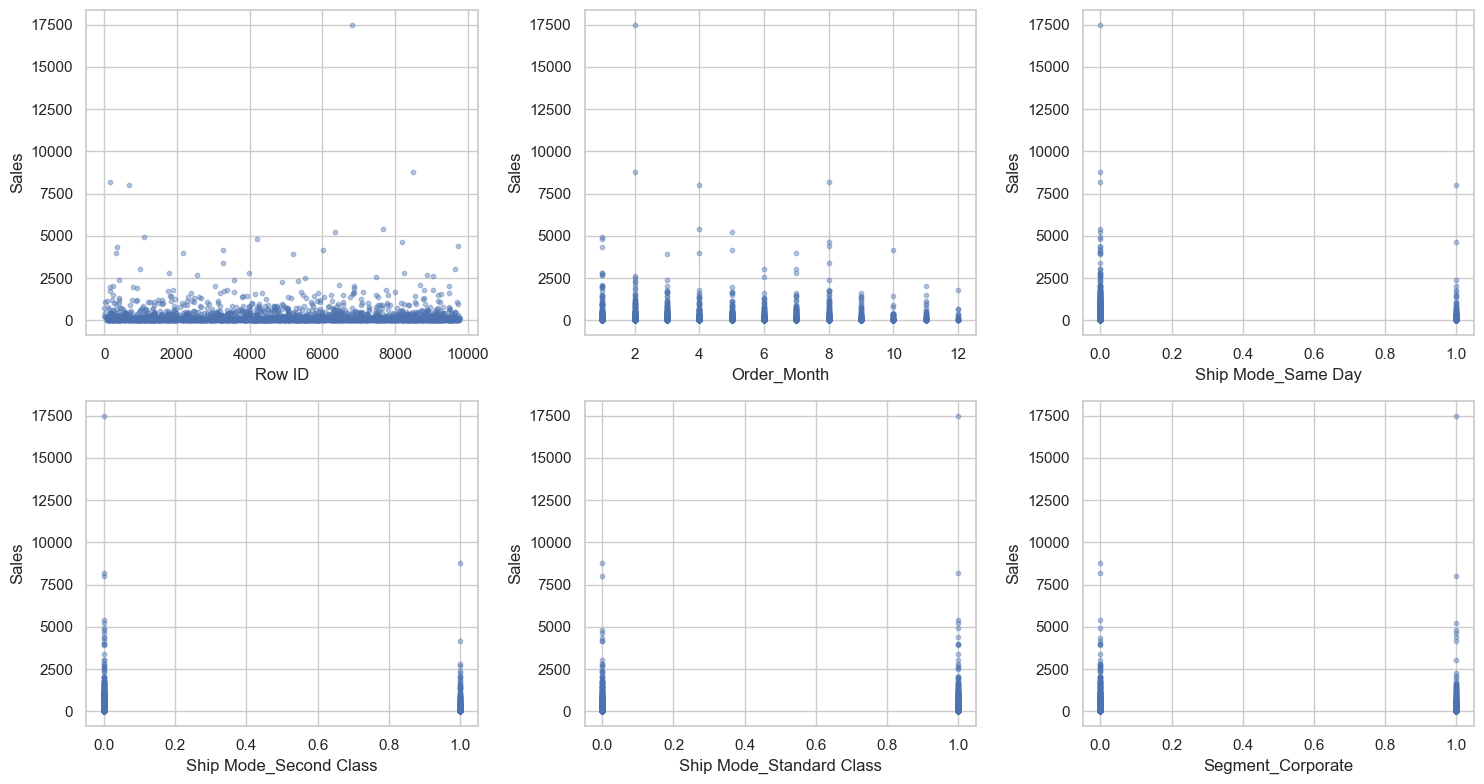

In [8]:
num_predictors = X.select_dtypes(include=[np.number]).columns[:6]  # first few for readability

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_predictors):
    ax.scatter(X[col], y, alpha=0.4, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

### 3.2 Check linearity assumption

**What:** Visually inspect the scatter plots above for a straight-line pattern (as opposed to curved, fanned,
or clustered patterns).

**Why:** Linear regression assumes E[Y|X] is a linear function of X. If the true relationship is curved,
a plain linear model will be biased — this check tells us whether we need polynomial/interaction terms
(Phase 3, tasks 9–10) or a transformation.

In [9]:
# Simple linearity check via correlation strength as a proxy
corrs = X[num_predictors].corrwith(y).sort_values(key=abs, ascending=False)
print(corrs)

Segment_Corporate           0.024627
Order_Month                -0.010151
Row ID                     -0.008135
Ship Mode_Second Class      0.004228
Ship Mode_Same Day          0.003887
Ship Mode_Standard Class    0.001578
dtype: float64


### 3.3 Fit a baseline model, then check normality of residuals (Q-Q plot)

**What:** Fit a first `LinearRegression` model, compute residuals, and plot them on a Q-Q plot against a
normal distribution.

**Why:** Valid confidence intervals and p-values for the coefficients rely on residuals being approximately
normally distributed. A Q-Q plot that deviates a lot from the diagonal line signals this assumption is
violated (common with skewed targets like Sales — may motivate a log-transform of Sales).

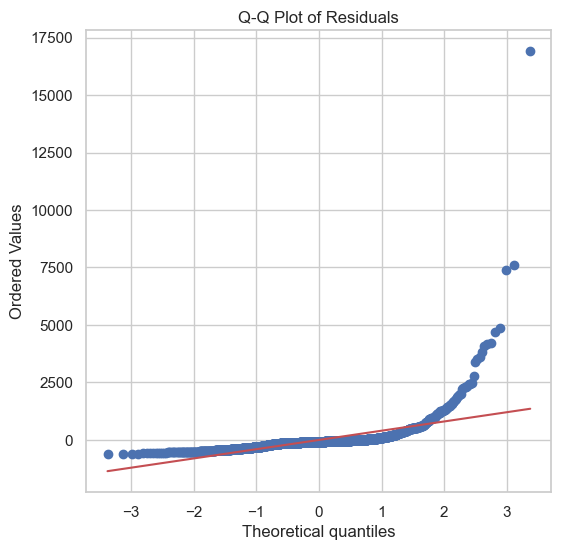

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

residuals = y_train - lr.predict(X_train)

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

### 3.4 Check homoscedasticity (residual plot)

**What:** Plot residuals against fitted (predicted) values.

**Why:** Linear regression assumes constant variance of errors (homoscedasticity). A funnel/cone shape in
this plot means variance grows with the prediction magnitude (heteroscedasticity), which makes standard
errors unreliable — again often fixed by transforming the target.

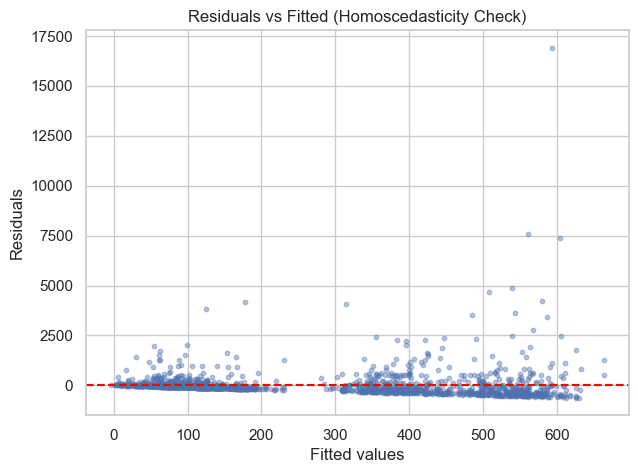

In [11]:
fitted = lr.predict(X_train)

plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals, alpha=0.4, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Homoscedasticity Check)")
plt.show()

### 3.5 Build the simple Linear Regression model

**What:** Fit `sklearn.linear_model.LinearRegression` on the training data (already done above as `lr`,
repeated here for clarity as the "official" model of this step).

**Why:** This is our baseline model — the simplest, most interpretable option, and the benchmark that
polynomial/Ridge/Lasso models will be compared against.

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Intercept:", lr.intercept_)
print("Number of coefficients:", len(lr.coef_))

Intercept: 465.4238060146288
Number of coefficients: 12


### 3.6 Evaluate using R² and RMSE

**What:** Compute R² (proportion of variance explained) and RMSE (average prediction error, in the same
units as Sales) on the test set.

**Why:** R² tells us how much of the variation in sales the model captures overall; RMSE gives a
business-interpretable error size (e.g. "predictions are off by $X on average"). Using both together
gives a fuller picture than either alone.

In [16]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R^2:  {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R^2:  0.0053
RMSE: 502.35


### 3.7 Plot actual vs predicted sales

**What:** Scatter plot of actual test-set Sales vs predicted Sales, with a 45° reference line.

**Why:** This is a quick visual sanity check — points close to the diagonal mean good predictions; a
systematic bend or spread reveals where the model over/under-predicts (e.g. for large orders).

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

### 3.8 Interpret coefficients in business terms

**What:** List each feature with its coefficient and explain what a one-unit increase means for predicted
sales, holding other features constant.

**Why:** The whole point of linear regression over a black-box model is interpretability — stakeholders
want to know "what drives sales," not just the prediction number.

In [ ]:
coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

coef_table

# Example interpretation (fill in with your actual top features):
# "Holding all else constant, each additional day of Shipping_Delay_Days is associated with
#  a change of $<coef> in predicted Sales." Positive coefficients push sales up, negative push it down.

### 3.9 Feature Engineering — interaction terms & polynomial features

**What:** Use `PolynomialFeatures` to automatically generate interaction terms (e.g. `feature_A * feature_B`)
and squared terms (e.g. `feature_A^2`) from the existing numeric predictors.

**Why:** Plain linear regression can only fit straight-line effects and cannot capture combined effects
between two variables (e.g. "delay matters more for big orders") or curved relationships. Polynomial/
interaction features let a still-linear model (linear in the *new* features) approximate nonlinear
patterns — this is the core feature-engineering step of the assignment.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_feature_names = poly.get_feature_names_out(X_train.columns)
print("Original features:", X_train.shape[1])
print("Features after degree=2 expansion:", X_train_poly.shape[1])

### 3.10 Build Polynomial Regression models (degree = 2, 3)

**What:** Fit `LinearRegression` on the degree-2 and degree-3 polynomial-expanded feature sets.

**Why:** Comparing degree 2 vs 3 shows the classic bias-variance tradeoff: higher degree can fit training
data better but risks overfitting (great train R², poor test R²).

In [ ]:
results = {}

for degree in [2, 3]:
    poly_d = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_d = poly_d.fit_transform(X_train)
    Xte_d = poly_d.transform(X_test)

    model_d = LinearRegression()
    model_d.fit(Xtr_d, y_train)

    pred_d = model_d.predict(Xte_d)
    results[f"Polynomial (deg={degree})"] = {
        "R2": r2_score(y_test, pred_d),
        "RMSE": mean_squared_error(y_test, pred_d, squared=False),
        "n_features": Xtr_d.shape[1]
    }

pd.DataFrame(results).T

### 3.11 Compare polynomial regression vs linear regression

**What:** Add the original (degree=1) linear model's metrics to the same comparison table.

**Why:** We need all models on one table to decide whether the added complexity of polynomial features
actually improves generalization (test performance), not just training fit.

In [ ]:
results["Linear (deg=1)"] = {
    "R2": r2,
    "RMSE": rmse,
    "n_features": X_train.shape[1]
}

comparison_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
comparison_df

### 3.12 Ridge regression — tune alpha

**What:** Fit `Ridge` regression (L2-regularized linear regression) across a range of `alpha` values and
pick the best one using cross-validation (`RidgeCV`).

**Why:** Polynomial expansion multiplies the number of features, which increases overfitting risk and
multicollinearity. Ridge shrinks coefficients toward zero (without eliminating them) to control this,
trading a bit of bias for lower variance.

In [ ]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_poly, y_train)

print("Best alpha:", ridge_cv.alpha_)

ridge_pred = ridge_cv.predict(X_test_poly)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = mean_squared_error(y_test, ridge_pred, squared=False)
print(f"Ridge R^2: {ridge_r2:.4f}, RMSE: {ridge_rmse:.2f}")

### 3.13 Lasso regression — tune alpha

**What:** Fit `Lasso` regression (L1-regularized) across a range of `alpha` values using `LassoCV`.

**Why:** Unlike Ridge, Lasso can shrink coefficients exactly to zero, effectively performing feature
selection — useful after polynomial expansion where many interaction terms are likely irrelevant.

In [ ]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_poly, y_train)

print("Best alpha:", lasso_cv.alpha_)
print("Number of features zeroed out:", np.sum(lasso_cv.coef_ == 0), "/", len(lasso_cv.coef_))

lasso_pred = lasso_cv.predict(X_test_poly)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = mean_squared_error(y_test, lasso_pred, squared=False)
print(f"Lasso R^2: {lasso_r2:.4f}, RMSE: {lasso_rmse:.2f}")

### 3.14 Compare Linear, Ridge, and Lasso

**What:** Put Linear, Ridge, and Lasso results (all on the polynomial feature set, for a fair comparison)
side by side.

**Why:** This tells us whether regularization actually helped — if Ridge/Lasso test R² beats plain Linear
on the same expanded feature set, regularization successfully controlled overfitting.

In [ ]:
final_comparison = pd.DataFrame({
    "Linear (poly deg=2)": {"R2": results["Polynomial (deg=2)"]["R2"],
                              "RMSE": results["Polynomial (deg=2)"]["RMSE"]},
    "Ridge (poly deg=2)": {"R2": ridge_r2, "RMSE": ridge_rmse},
    "Lasso (poly deg=2)": {"R2": lasso_r2, "RMSE": lasso_rmse},
}).T

final_comparison

### 3.15 Cross-validation (5-fold) for all models

**What:** Run 5-fold cross-validation for Linear, Ridge, and Lasso and report mean ± std of R².

**Why:** A single train/test split can be lucky or unlucky. 5-fold CV gives a more robust estimate of
how each model is expected to perform on new data, and the std tells us how stable that performance is.

In [ ]:
from sklearn.model_selection import cross_val_score

models_to_cv = {
    "Linear": (LinearRegression(), X_train_poly),
    "Ridge": (Ridge(alpha=ridge_cv.alpha_), X_train_poly),
    "Lasso": (Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_train_poly),
}

from sklearn.linear_model import Ridge, Lasso

cv_results = {}
for name, (model, Xd) in models_to_cv.items():
    scores = cross_val_score(model, Xd, y_train, cv=5, scoring="r2")
    cv_results[name] = {"mean_R2": scores.mean(), "std_R2": scores.std()}

pd.DataFrame(cv_results).T

## Summary

- Preprocessing removed missing values and multicollinear features (VIF > 10).
- Feature engineering (date parts, shipping delay, one-hot encoding, and polynomial/interaction terms)
  turned raw columns into predictors a linear model can use.
- Polynomial regression captured nonlinearity that plain linear regression missed, at the cost of more
  features and higher overfitting risk.
- Ridge and Lasso regularization controlled that overfitting; compare the final table above to decide
  which model to report as your final choice, and justify it using the R²/RMSE/CV results.